# @property geschwindigkeit und @geschwindigkeit.setter
## ohne geschwindigkeit.setter wird das alte property obejkt nur mit fget in der class.__dict__ gespeichert, mit geschwindigkeit.setter wird aber das neue property object mit fget, fset  in class.__dict__ bei Erzeugung der Klasse  gespeichert. Dann ist das ojketc fertig.
## danach bei der Laufzeit wird direkt __get__ oder __set__ aus dem class.__dict__ gespeicherte property object  benutzt?

https://chatgpt.com/c/695aba23-921c-832e-8088-9473ffd99807

https://www.google.com/search?sca_esv=1e06d8258b4a5573&sxsrf=AE3TifMKGDjn0RuGPJPAtT8uxo5mIKN2kw%3A1767549066048&source=hp&ei=iqhaaY-SAauWxc8Pme_nsAo&iflsig=AOw8s4IAAAAAaVq2mqHxMzmJgDwMq3PbxS6papJFNwrm&aep=26&udm=50&ved=0CAAQ2_wOahcKEwjAwMKzufKRAxUAAAAAHQAAAAAQDA&oq=&gs_lp=Egdnd3Mtd2l6IgBIAFAAWABwAHgAkAEAmAEAoAEAqgEAuAEByAEAmAIAoAIAmAMAkgcAoAcAsgcAuAcAwgcAyAcAgAgA&sclient=gws-wiz&atvm=1&mstk=AUtExfCVzCo14eSkays2LKmPgu1BNoPPzL7RaGo98iAaK30Hd1Uvacrni1k8ULuoO15SiF2t7zGLM2DFGGl2js1IdyHw9Sa1X__tdQu_oQW5vmKl6vWqAS-YDmPJAfUMg07R2BIUDdWg3x3rI2paTi7WXBEwXyW58cv5ZXkFLRue7l-wEOcVRAH28kzzuGtE7VFtRET3arEt-xrLM9iwxIi-dwr2u4gf2FQYQphVJnXqFZd5mUFu8qY5itJWqy8TuCB9w3rtVEzkrkP8BW3HKWw2nFfUzynmNfI9uuJ_VV68dZClpL8pfHpDqI3ScJeCW_374zncQ84OoM5p9A&mtid=Uy9YaeXnKuHt7_UPtvOn4QE&csuir=1&q=Was+ist+ein+Attribut+in+Python%3F%0AAttribut+%3D+alles%2C+was+%C3%BCber+den+Punktoperator+erreichbar+ist%3F


## Ich überlege
Genau richtig! Du hast den gesamten Lebenszyklus einer Property perfekt zusammengefasst.
Hier ist die Bestätigung der zwei Phasen (Stand 2026):
 1. Phase: Erzeugung der Klasse (Definition)
Hier wird entschieden, welches "Werkzeug" (Property-Objekt) in das __dict__ der Klasse gelegt wird:

    - Fall A (Nur @property):
    Im class.__dict__ wird ein Property-Objekt gespeichert, bei dem nur das Feld fget belegt ist. Das Feld fset ist leer (None).
    - Fall B (Mit @geschwindigkeit.setter):
    Zuerst wird das Objekt aus Fall A erzeugt. Dann wird durch den Setter-Decorator ein neues Property-Objekt erzeugt, das sowohl fget als auch fset enthält. Dieses neue Objekt überschreibt das alte im class.__dict__.

    Am Ende dieser Phase hat die Klasse also genau ein fertiges Property-Objekt in ihrem Namensraum liegen.
 2. Phase: Laufzeit (Zugriff über a.geschwindigkeit)
Jetzt wird nicht mehr mit Decorators oder neuen Objekten hantiert. Python nutzt das bereits in der Klasse existierende Objekt als Descriptor:

 3. Beim Lesen (a.geschwindigkeit):
    - Python führt class.__dict__['geschwindigkeit'].__get__(a, Auto) aus. Da fget vorhanden ist, wird deine Funktion aufgerufen.
    - Beim Schreiben (a.geschwindigkeit = 100):
        - Python führt class.__dict__['geschwindigkeit'].__set__(a, 100) aus.
        - Wenn es aus Fall A stammt: __set__ sieht, dass fset leer ist -> AttributeError.
        - Wenn es aus Fall B stammt: __set__ sieht, dass fset belegt ist -> Deine Setter-Funktion wird aufgerufen.

In [2]:
class Property:
    """Nachbildung der eingebauten property-Klasse."""

    def __init__(self, fget=None, fset=None, fdel=None, doc=None):
        self.fget = fget
        self.fset = fset
        self.fdel = fdel
        if doc is None and fget is not None:
            self.__doc__ = fget.__doc__
        else:
            self.__doc__ = doc

    # Das Descriptor-Protokoll: Das Herzstück
    def __get__(self, obj, objtype=None):
        if obj is None:
            # Zugriff über die Klasse (z.B. Auto.geschwindigkeit)
            return self
        if self.fget is None:
            raise AttributeError("unreadable attribute")
        # Ruft deine @property-Methode auf und übergibt die Instanz (self)
        return self.fget(obj)

    def __set__(self, obj, value):
        if self.fset is None:
            # Hier passiert der Fehler, wenn kein @setter definiert wurde!
            raise AttributeError("can't set attribute")
        # Ruft deine @name.setter-Methode auf
        self.fset(obj, value)

    def __delete__(self, obj):
        if self.fdel is None:
            raise AttributeError("can't delete attribute")
        self.fdel(obj)

    # Die Methoden für die Decorator-Syntax
    def setter(self, fset):
        # Erzeugt eine NEUE Property-Instanz mit dem hinzugefügten Setter
        return type(self)(self.fget, fset, self.fdel, self.__doc__)

    def deleter(self, fdel):
        return type(self)(self.fget, self.fset, fdel, self.__doc__)


## 1️⃣ Kurzantwort (Essenz)

 - ✔️ Methoden sind Descriptors, weil Funktionen Descriptors sind
 - ✔️ Es gibt NICHT für jede Methode ein eigenes __get__
 - ✔️ Alle Methoden benutzen dieselbe function.__get__-Implementierung
 - ✔️ Das „Binden“ von self passiert in __get__
 - ✔️ durch @property wird geschwindigkeit zu property(object), nicht mehr function(object), achten auf diesen Unterschied!!
 - das sieht man beim Ausdruck von Auto.__dict__: 'geschwindigkeit': <property object at 0x00000168F05324D0>

## Intern macht Python:

- Erzeugt ein leeres Klassennamespace-Dictionary

- Führt den Code im Klassenrumpf aus

- Alles, was dort definiert wird, landet in diesem Namespace

- Danach wird Auto = type("Auto", (), namespace) aufgerufen

In [26]:
class Auto:
    @property   #durch @property wird geschwindigkeit zu property(object), nicht mehr function(object), achten auf diesen Unterschied!!
    def geschwindigkeit(self):      # fget
        return 42

    @geschwindigkeit.setter
    def geschwindigkeit(self, v):   # fset
        print(f"Setze auf {v}")
myauto=Auto()
print( Auto.__dict__)

{'__module__': '__main__', 'geschwindigkeit': <property object at 0x00000168F05324D0>, '__dict__': <attribute '__dict__' of 'Auto' objects>, '__weakref__': <attribute '__weakref__' of 'Auto' objects>, '__doc__': None}


# class function

## class function: and class  method:  are python intern class:

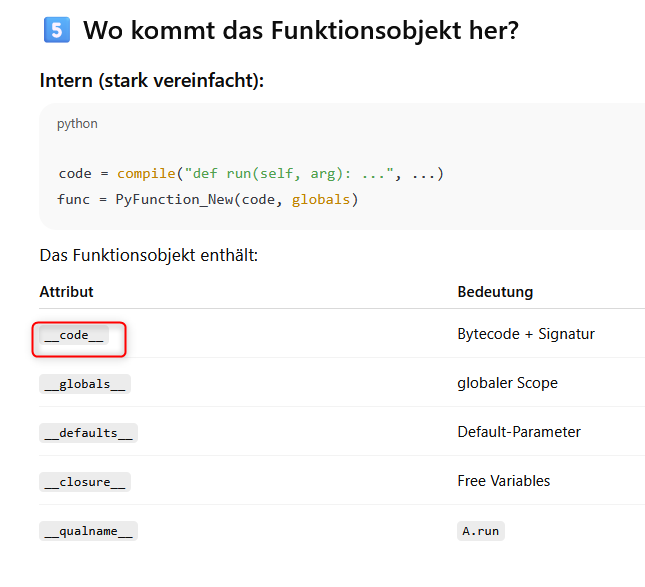

wird der Code in run(self, arg) in __code__ gespeichert?

ja — exakt.

Der komplette Code von run(self, arg) wird als Bytecode im __code__-Objekt gespeichert.
Und das ist kein Bild, sondern ein konkretes, inspizierbares Objekt.

Ich gehe von Quelle → Bytecode → __code__ → Ausführung.

https://chatgpt.com/c/695aba23-921c-832e-8088-9473ffd99807


In [29]:
class A:
    def run(self):
        print("-> call run")
        print("self =", self)

a = A()
print( A.__dict__)
func_obj = A.__dict__['run']

print(func_obj)
print("-> type: ", type(func_obj))  # ein instance(object)  of class function
print("-> func_obj.__get__: ", func_obj.__get__) # func_obj hat __get__() als wrapper

print("->: bound method=> a.run :", a.run)  # a.run is bound method (object of method) because a is bound with run
print("->A.run.__get__:", A.run.__get__)
a.run()   # woher kommt self?


{'__module__': '__main__', 'run': <function A.run at 0x0000020513FE00E0>, '__dict__': <attribute '__dict__' of 'A' objects>, '__weakref__': <attribute '__weakref__' of 'A' objects>, '__doc__': None}
<function A.run at 0x0000020513FE00E0>
-> type:  <class 'function'>
-> func_obj.__get__:  <method-wrapper '__get__' of function object at 0x0000020513FE00E0>
->: bound method=> a.run : <bound method A.run of <__main__.A object at 0x0000020513B112E0>>
->A.run.__get__: <method-wrapper '__get__' of function object at 0x0000020513FE00E0>
-> call run
self = <__main__.A object at 0x0000020513B112E0>


# 1.2 Warum gibt es keinen globalen Namen function (method)?

Weil function:

in C implementiert ist

nicht automatisch in den Python-Namensraum importiert wird

kein Built-in-Identifier ist (anders als int, list, dict)

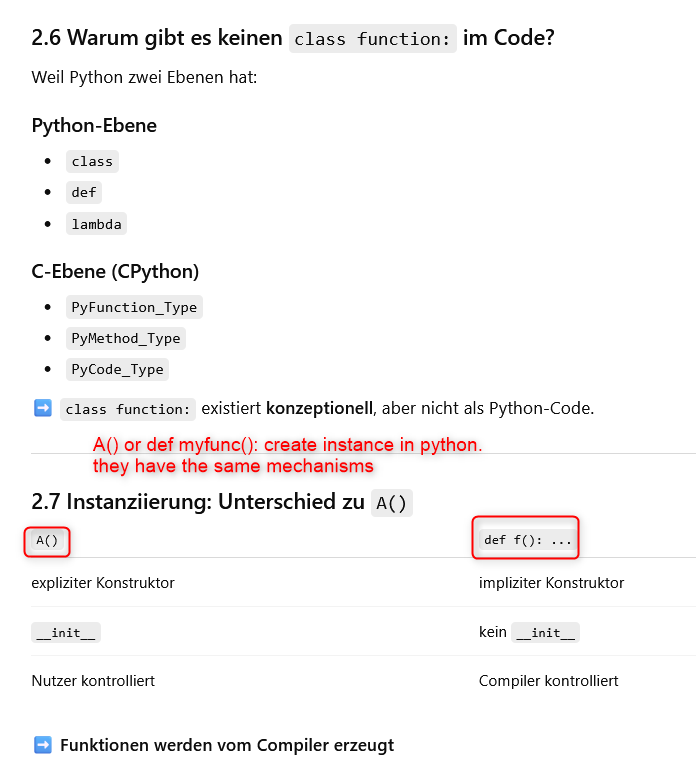

# 2.8 Visualisierung
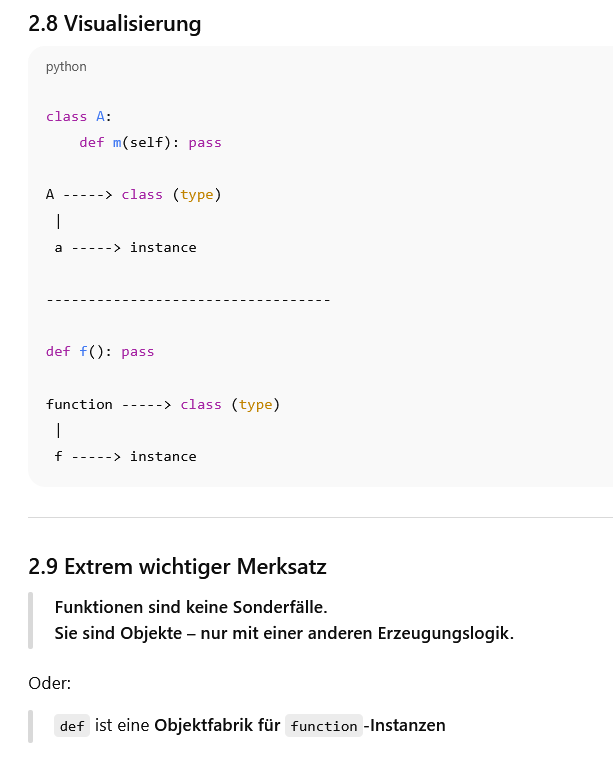

In [43]:
# run ist ein eine Instanz von  class function
print(type(A.run))
print(hasattr(A.run, "__get__"))
# myfunc= function() # name 'function' is not defined
# function ist der Typname, aber kein globaler Bezeichner.
f = lambda x: x
print("f:", type(f))
from types import FunctionType 
print(FunctionType)

from types import MethodType # wie FunctionType 
print("MethodType:", MethodType)
print("MethodType type:",type(MethodType))
print("type of a: ", type(a))
print("type(a.run):", type(a.run))
print("a.run:", a.run)
print(list)
print(type(list))
print(dict)
print(type(dict))
#print(method) # name 'method' is not defined in python, aber in C-implentation

print(A)
print(type(A))



<class 'function'>
True
f: <class 'function'>
<class 'function'>
MethodType: <class 'method'>
MethodType type: <class 'type'>
type of a:  <class '__main__.A'>
type(a.run): <class 'method'>
a.run: <bound method A.run of <__main__.A object at 0x0000020513B112E0>>
<class 'list'>
<class 'type'>
<class 'dict'>
<class 'type'>
<class '__main__.A'>
<class 'type'>


In [18]:
# A.run =A.__dict__['run'].__get__(None, A)
A.__dict__['run'].__get__(None, A)


<function __main__.A.run(self)>

In [24]:
# a.run = A.__dict__['run'].__get__(a, A)
bound= A.__dict__['run'].__get__(a, A)
print(type(bound))
print(bound)
A.__dict__['run'].__get__(a, A)


<class 'method'>
<bound method A.run of <__main__.A object at 0x00000168EFDA95E0>>


<bound method A.run of <__main__.A object at 0x00000168EFDA95E0>>

In [25]:
print(bound.__func__)
print(bound.__self__)


<function A.run at 0x00000168EFF7C900>
